In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA

In [2]:
df=pd.read_csv("LIMFADD.csv")
print("File read successfully")

File read successfully


In [3]:
df.shape

(15000, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Followers            15000 non-null  int64 
 1   Following            15000 non-null  int64 
 2   Following/Followers  15000 non-null  object
 3   Posts                15000 non-null  int64 
 4   Posts/Followers      15000 non-null  object
 5   Bio                  15000 non-null  object
 6   Profile Picture      15000 non-null  object
 7   External Link        15000 non-null  object
 8   Mutual Friends       15000 non-null  int64 
 9   Threads              15000 non-null  object
 10  Labels               15000 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.3+ MB


In [5]:
df.head()

,Followers,Following,Following/Followers,Posts,Posts/Followers,Bio,Profile Picture,External Link,Mutual Friends,Threads,Labels
0,2,2757,1378.5,0,0,N,N,N,0,N,Bot
1,2,505,252.5,0,0,N,Yes,N,0,N,Scam
2,6786,1782,0.262599469,1589,6051.040404,yes,N,Yes,10,N,Real
3,21,1281,61,0,0,N,Yes,N,0,N,Bot
4,585,1682,2.875213675,2663,926.1920333,yes,N,N,12,Yes,Real


In [6]:
df.dtypes

Followers               int64
Following               int64
Following/Followers    object
Posts                   int64
Posts/Followers        object
Bio                    object
Profile Picture        object
External Link          object
Mutual Friends          int64
Threads                object
Labels                 object
dtype: object

In [7]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
print(df.columns)


Index(['Followers', 'Following', 'Following/Followers', 'Posts',
       'Posts/Followers', 'Bio', 'Profile_Picture', 'External_Link',
       'Mutual_Friends', 'Threads', 'Labels'],
      dtype='object')


In [8]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')


C:\Users\HP\AppData\Local\Temp\ipykernel_19716\3070116034.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [9]:
df.isna().sum()


Followers              0
Following              0
Following/Followers    0
Posts                  0
Posts/Followers        0
Bio                    0
Profile_Picture        0
External_Link          0
Mutual_Friends         0
Threads                0
Labels                 0
dtype: int64

In [10]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
print(df.columns)


Index(['Followers', 'Following', 'Following/Followers', 'Posts',
       'Posts/Followers', 'Bio', 'Profile_Picture', 'External_Link',
       'Mutual_Friends', 'Threads', 'Labels'],
      dtype='object')


In [11]:
df = df.replace(["#DIV/0!", "NaN", "nan", ""], np.nan)


In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


In [13]:
corr = df.select_dtypes(include=[np.number]).corr()
print(corr)


                Followers  Following     Posts  Mutual_Friends
Followers        1.000000  -0.271182  0.045134        0.238138
Following       -0.271182   1.000000 -0.146377       -0.206621
Posts            0.045134  -0.146377  1.000000        0.586797
Mutual_Friends   0.238138  -0.206621  0.586797        1.000000


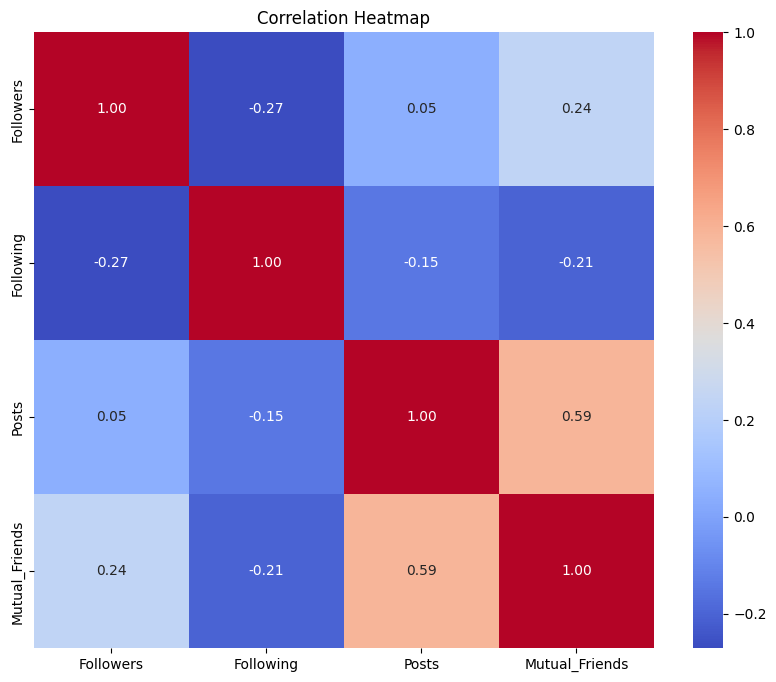

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

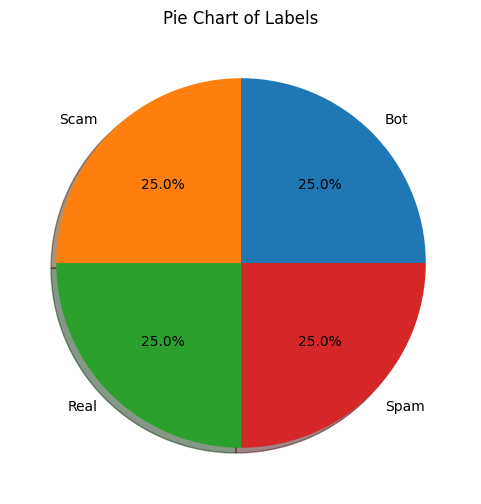

In [15]:
plt.figure(figsize=(6,6))
df['Labels'].value_counts().plot(kind='pie', autopct='%1.1f%%', shadow=True)
plt.title("Pie Chart of Labels")
plt.ylabel("")  # remove y-label
plt.show()


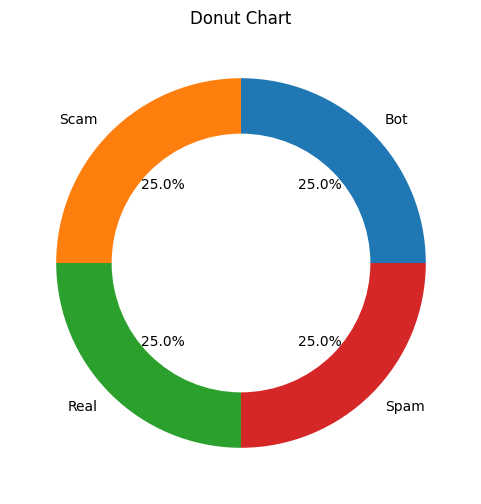

In [16]:
plt.figure(figsize=(6,6))
sizes = df['Labels'].value_counts()
plt.pie(sizes, labels=sizes.index, autopct='%1.1f%%')
centre = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre)
plt.title("Donut Chart")
plt.show()


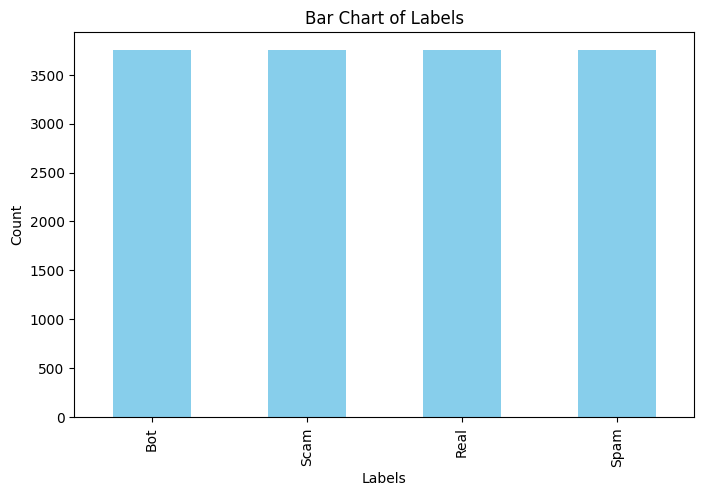

In [17]:
plt.figure(figsize=(8,5))
df['Labels'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Bar Chart of Labels")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.show()


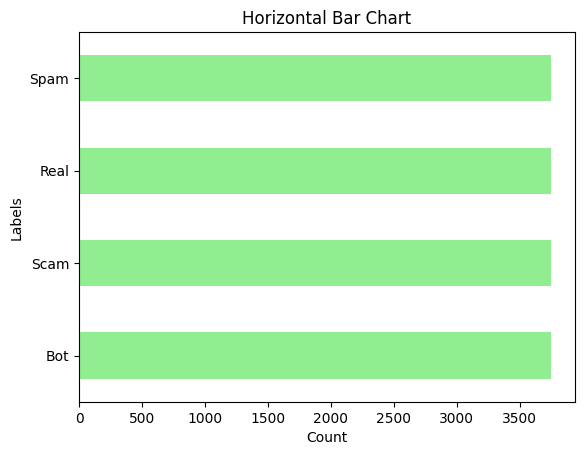

In [18]:
df['Labels'].value_counts().plot(kind='barh', color='lightgreen')
plt.title("Horizontal Bar Chart")
plt.xlabel("Count")
plt.ylabel("Labels")
plt.show()


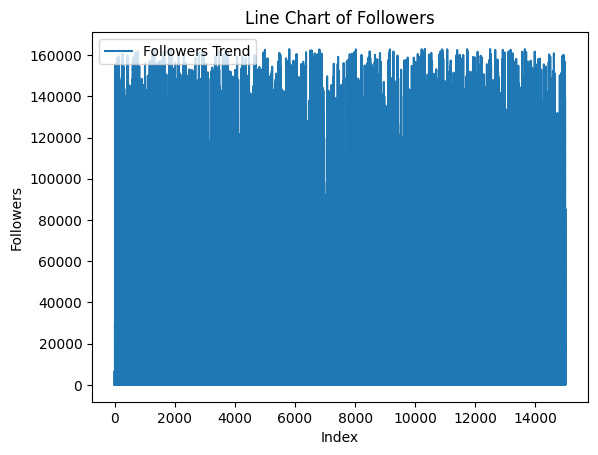

In [19]:
plt.plot(df['Followers'], label="Followers Trend")
plt.title("Line Chart of Followers")
plt.xlabel("Index")
plt.ylabel("Followers")
plt.legend()
plt.show()


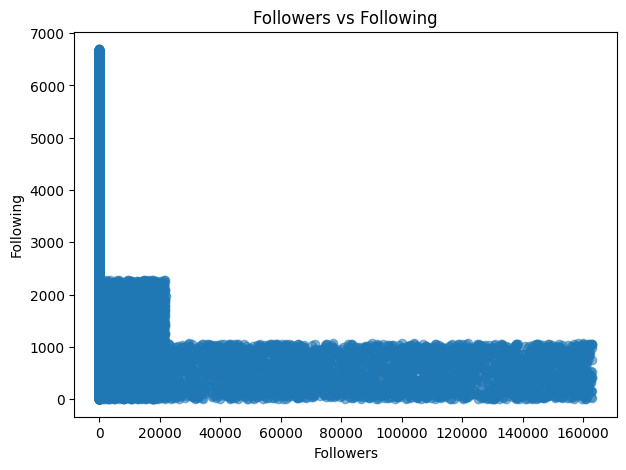

In [20]:
plt.figure(figsize=(7,5))
plt.scatter(df['Followers'], df['Following'], alpha=0.5)
plt.title("Followers vs Following")
plt.xlabel("Followers")
plt.ylabel("Following")
plt.show()


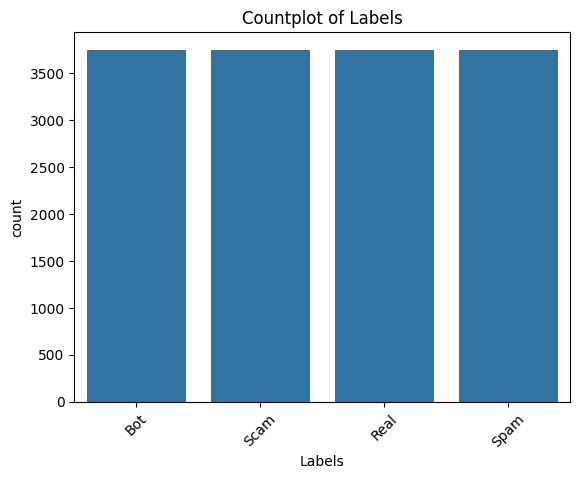

In [21]:
sns.countplot(data=df, x='Labels')
plt.title("Countplot of Labels")
plt.xticks(rotation=45)
plt.show()


In [22]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":      # only string columns
        df[col] = df[col].astype(str)  # ensure string
        df[col] = le.fit_transform(df[col])

In [23]:
X = df.drop("Followers", axis=1)
y = df["Followers"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [25]:
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))


R2 Score: 0.6528364043886643
MSE: 594229337.176203


In [26]:
df["Followers_high"] = (df["Followers"] > df["Followers"].median()).astype(int)

X = df.drop(["Followers","Followers_high"], axis=1)
y = df["Followers_high"]


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [28]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_log = logreg.predict(X_test)


In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))


Accuracy: 0.9983333333333333
Confusion Matrix:
 [[1501    1]
 [   4 1494]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1502
           1       1.00      1.00      1.00      1498

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



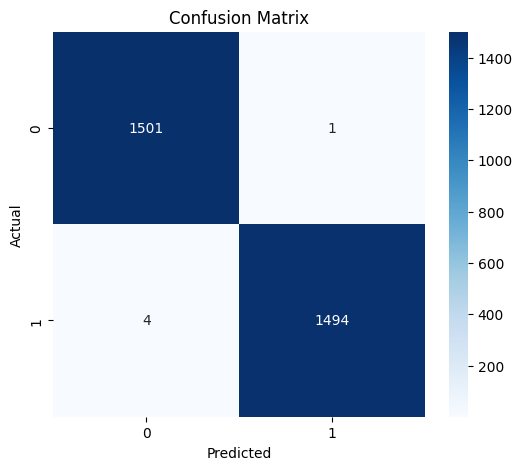

In [38]:
# Confusion matrix calculate
cm = confusion_matrix(y_test, y_pred_log)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
numeric_df = df.select_dtypes(include=[np.number])

In [31]:
y_num = df["Followers_high"] 

In [32]:
X = numeric_df.drop("Followers_high", axis=1)

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.38664286 0.15100141]


In [35]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

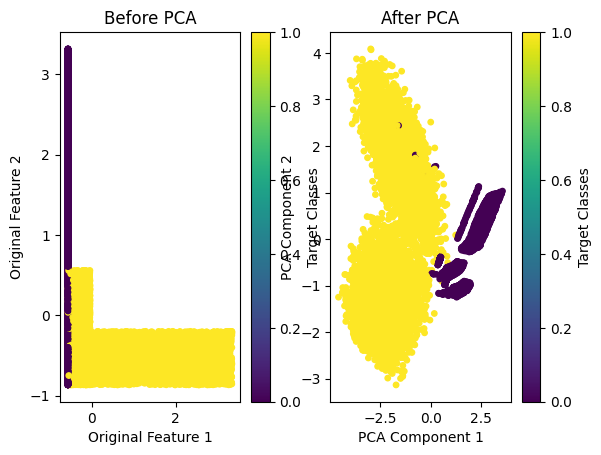

In [36]:
# BEFORE PCA
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_num, s=15, cmap='viridis')
plt.xlabel("Original Feature 1")
plt.ylabel("Original Feature 2")
plt.title("Before PCA")
plt.colorbar(label="Target Classes")

# AFTER PCA
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_num, s=15, cmap='viridis')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("After PCA")
plt.colorbar(label="Target Classes")

            
plt.show()
